# 2.4 — Обучение DPI-EVT

**Папка 2 «Обучение», подноутбук 4.** DPI-EVT — гибрид: энкодер DPI-Flow выводит латент θ, из
которого строится **развязанная (decoupled)** граница CRR и траектория PPR(N), а число циклов
до разжижения берётся **из самой кривой PPR** (`nliq_from_curve=True`). Это делает модель
согласованным источником PPR, CRR, риска и N_liq без утверждений о лидерстве внутри training notebook.
Актуальные места моделей определяются только в `results/tables/*.csv`, которые пересчитывает серия `3_*`.

Раньше DPI-EVT обучался отдельным скриптом `run_dpievt.py` и не имел своего ноутбука — из-за
чего при чистой папке `models/` он терял веса и выпадал из оценки. Этот ноутбук **штатно**
обучает, калибрует и сохраняет DPI-EVT, повторяя ту же процедуру:

* фиксированный seed, **косинусный планировщик LR** (`scheduler="cosine"`) — ключ к качеству;
* развязанная CRR + N_liq из кривой, без traj-residual и без внутренней калибровки θ;
* пост-hoc калибровка ширины интервалов (`fit_interval_scale`).

> Важно: качество DPI-EVT чувствительно к косинусному расписанию LR — обычный прогон
> `train_model` без планировщика заметно его ухудшает.


## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch
from liquefaction_ai import (get_default_config, load_population_artifact,
                             prepare_benchmark_dataset, train_model, set_global_seed)
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, fit_interval_scale
from liquefaction_ai.models import DPIEvtNet

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
static_dim = train["static"].shape[1]; prefix_dim = train["prefix_summary"].shape[1]
seq_dim = train["seq_in"].shape[-1]
print("Источник:", DATA_DIR.name, "| train/val/test:",
      train["static"].shape[0], val["static"].shape[0], test["static"].shape[0],
      "| static_dim:", static_dim)

Источник: dataset | train/val/test: 471 118 223 | static_dim: 38


## Шаг 1. Конфигурация и сборка модели

Параметры DPI-EVT соответствуют рабочей конфигурации: развязанная CRR, N_liq из кривой,
вероятностная голова и flow, без traj-residual и без внутренней калибровки θ.

**Порог разжижения.** `liq_threshold` берётся из общего конфига (`config.liq_threshold`) и
сохраняется в `models/dpi_evt/hyperparams.json`, поэтому training notebook, модельный артефакт
и оценка используют один и тот же порог. В текущем артефакте это `0.95`; итоговые значения
N_liq, CRR, Brier и CRPS не фиксируются в тексте ноутбука, а читаются из таблиц серии `3_*`.


In [2]:
MC_SOTA = False   # #3: включить MC-mixture обучение неопределённости DPI-EVT
SELECTION_METRIC = "Traj_RMSE_continuation"   # метрика отбора лучшей комбинации
fixed = dict(
    static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim,
    seq_len=config.seq_len, prefix_len=config.prefix_len,
    max_cycle_reference=config.max_cycle_reference,
    probabilistic=True, use_flow=False,                 # поток дестабилизирует EVT-движок
    nliq_from_curve=True, liq_threshold=config.liq_threshold,
    use_traj_residual=False,
    # MC-микстура (#3): калибрует разброс гауссова постериора под предиктивную ошибку
    # (mixture-NLL + energy-CRPS). MC_SOTA=False → прежнее поведение. use_flow остаётся False.
    **(dict(mc_train_samples=4, mc_crps_weight=0.3) if (globals().get('MC_SOTA', False)) else dict()),
)
# Разнообразный грид DPI-EVT: ёмкость энкодера × способ построения отчётной CRR × глубина
# дифференцируемой калибровки θ по префиксу. crr_mode — ключевая ось проекта (decoupled снимает
# компромисс «траектория↔CRR», hybrid/damage — альтернативы).
grid = {"hidden_dim": [128, 160, 192],
        "crr_mode": ["decoupled", "hybrid", "damage"],
        "calibration_steps": [0, 1]}
res, best = grid_search(lambda p: DPIEvtNet(**fixed, **p), grid, train, val,
                        config, device, search_epochs=config.grid_search_epochs,
                        score_metric=SELECTION_METRIC)
print("Selection metric:", SELECTION_METRIC, "| best:", best)
display(res.head(8))

model_kwargs = {**fixed, **best}
EPOCHS = config.publication_physics_epochs
set_global_seed(config.seed)          # единый сид проекта (детерминированная инициализация)
model = DPIEvtNet(**model_kwargs).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("DPI-EVT параметров:", f"{n_params:,}", "| эпох:", EPOCHS)

Selection metric: Traj_RMSE_continuation | best: {'hidden_dim': 128, 'crr_mode': 'decoupled', 'calibration_steps': 0}


,hidden_dim,crr_mode,calibration_steps,val_loss,N_liq_MAE,N_liq_RMSE,N_liq_logMAE,N_liq_logRMSE,N_liq_n_observed,Supports_Censored_Nliq,...,Traj_NLL,Traj_CRPS,CRR_RMSE,N_CRR_test,N_CRR_objects,Produces_CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,128,decoupled,0,-0.727381,653.912781,1091.268188,1.191946,1.539457,118.0,1.0,...,-0.729637,0.050370,0.133468,70.0,1.0,1.0,0.054538,0.078067,1.135970,2.0
1,128,decoupled,1,-0.771561,653.895386,1091.243774,1.191923,1.539432,118.0,1.0,...,-0.729420,0.050373,0.133468,70.0,1.0,1.0,0.054539,0.078069,1.135950,2.0
2,160,damage,1,-0.554350,595.901367,1047.753906,1.103486,1.435502,118.0,1.0,...,-1.005107,0.051507,0.150875,70.0,1.0,1.0,0.063294,0.083457,1.050919,2.0
3,160,damage,0,-0.554380,595.901428,1047.754028,1.103486,1.435502,118.0,1.0,...,-1.005107,0.051507,0.150875,70.0,1.0,1.0,0.063294,0.083457,1.050919,2.0
4,192,decoupled,1,-1.001464,616.529358,1069.277222,1.163416,1.484059,118.0,1.0,...,-0.919174,0.053591,0.100215,70.0,1.0,1.0,0.070033,0.081930,1.108414,2.0
5,192,decoupled,0,-1.000016,616.529358,1069.277222,1.163416,1.484060,118.0,1.0,...,-0.919174,0.053591,0.100215,70.0,1.0,1.0,0.070033,0.081930,1.108414,2.0
6,128,hybrid,0,-0.755969,484.314056,942.702637,0.907660,1.273183,118.0,1.0,...,-0.509965,0.051193,0.148607,70.0,1.0,1.0,0.060073,0.081346,0.884461,2.0
7,128,hybrid,1,-0.707071,484.372375,942.787170,0.907742,1.273265,118.0,1.0,...,-0.509718,0.051199,0.148607,70.0,1.0,1.0,0.060064,0.081353,0.884536,2.0


DPI-EVT параметров: 244,517 | эпох: 200


## Шаг 2. Обучение с косинусным планировщиком LR

Это ключевой момент: косинусное расписание шага обучения существенно улучшает сходимость
DPI-EVT по сравнению с обычным прогоном.

In [3]:
model, history = train_model(model, train, val, epochs=EPOCHS, model_name="DPI-EVT",
                             config=config, device=device, track_metrics=True,
                             scheduler="cosine", ema_decay=0.0)
display(history)

[DPI-EVT] эпоха 01 | обучение=0.9611 | валидация=-0.7163 | val_AUROC=0.888 | val_RMSE=0.1673 | stale=0/25
[DPI-EVT] эпоха 02 | обучение=-0.5936 | валидация=-1.1406 | val_AUROC=0.932 | val_RMSE=0.1255 | stale=0/25
[DPI-EVT] эпоха 03 | обучение=-1.1362 | валидация=-1.2667 | val_AUROC=0.947 | val_RMSE=0.1167 | stale=0/25
[DPI-EVT] эпоха 04 | обучение=-1.2735 | валидация=-1.3347 | val_AUROC=0.950 | val_RMSE=0.1099 | stale=0/25
[DPI-EVT] эпоха 05 | обучение=-1.4319 | валидация=-1.4235 | val_AUROC=0.952 | val_RMSE=0.1078 | stale=0/25
[DPI-EVT] эпоха 06 | обучение=-1.5671 | валидация=-1.5083 | val_AUROC=0.961 | val_RMSE=0.1001 | stale=0/25
[DPI-EVT] эпоха 07 | обучение=-1.7237 | валидация=-1.5543 | val_AUROC=0.963 | val_RMSE=0.0930 | stale=0/25
[DPI-EVT] эпоха 08 | обучение=-1.8879 | валидация=-1.3779 | val_AUROC=0.966 | val_RMSE=0.1006 | stale=1/25
[DPI-EVT] эпоха 09 | обучение=-2.0107 | валидация=-1.5155 | val_AUROC=0.965 | val_RMSE=0.0909 | stale=2/25
[DPI-EVT] эпоха 10 | обучение=-2.1444 

,epoch,train_loss,val_loss,val_auroc,val_brier,val_traj_rmse,best_val_loss,epochs_without_improvement,best_epoch
0,1,0.961147,-0.716259,0.888081,0.157115,0.167293,-0.716259,0,1
1,2,-0.593646,-1.140624,0.932049,0.112200,0.125521,-1.140624,0,2
2,3,-1.136169,-1.266712,0.946584,0.087638,0.116658,-1.266712,0,3
3,4,-1.273496,-1.334730,0.949855,0.080838,0.109885,-1.334730,0,4
4,5,-1.431948,-1.423514,0.952035,0.088064,0.107844,-1.423514,0,5
5,6,-1.567142,-1.508337,0.960756,0.094878,0.100115,-1.508337,0,6
6,7,-1.723709,-1.554315,0.963299,0.108993,0.093015,-1.554315,0,7
7,8,-1.887863,-1.377861,0.966206,0.138326,0.100568,-1.554315,1,7
8,9,-2.010668,-1.515535,0.965480,0.128793,0.090892,-1.554315,2,7
9,10,-2.144354,-1.370714,0.970567,0.129800,0.093466,-1.554315,3,7


## Шаг 3. Кривые обучения

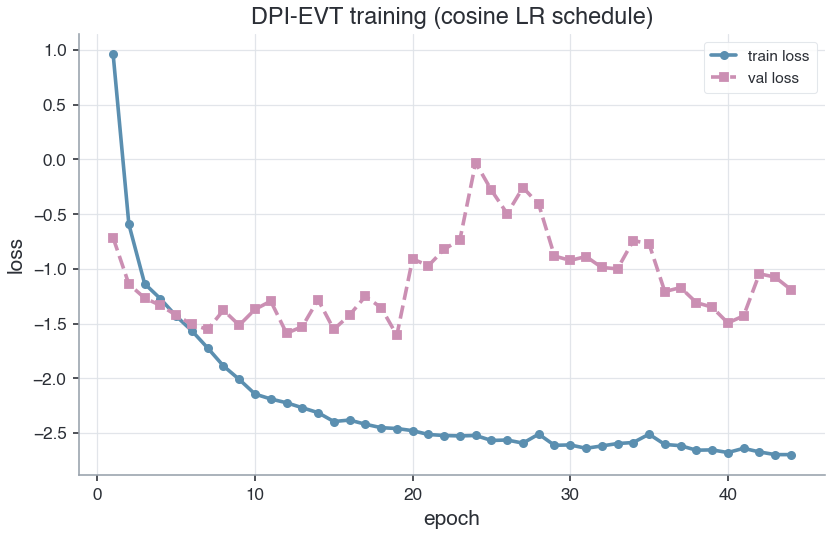

In [4]:
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, GRID
figw, fig = new_figure((7.4, 4.4)); ax = fig.add_subplot(111)
ax.plot(history["epoch"], history["train_loss"], "-o", color=QUALITATIVE[0], label="train loss", markersize=4)
ax.plot(history["epoch"], history["val_loss"], "--s", color="#CB8FB3", label="val loss", markersize=4)
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
if "val_AUROC" in history.columns:
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(history["epoch"], history["val_AUROC"], "-^", color="#7FB286", label="val AUROC", markersize=4)
    ax2.set_ylabel("val AUROC"); ax2.set_ylim(0.9, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="center right")
else:
    ax.legend(fontsize=8.5)
ax.set_title("DPI-EVT training (cosine LR schedule)")
save_figure(figw, "2_4_dpi_evt_training", SAVE_FIGS)
figw

## Шаг 4. Калибровка интервалов и оценка на тесте

`fit_interval_scale` подбирает масштаб ширины интервалов по валидации (целевое покрытие 90 %).
Затем считаем полный набор метрик на тестовой выборке.

In [5]:
calib_scale = fit_interval_scale(model, val, config, device, level=0.90)
metrics, _ = compute_metrics("DPI-EVT", collect_outputs(model, test, config, device), test, config)
keys = [("PPR Traj_RMSE", "Traj_RMSE"), ("Traj CRPS", "Traj_CRPS"), ("Calibration err", "Calibration_Error"),
        ("AUROC", "AUROC"), ("Brier", "Brier"), ("Physics violation", "Physics_Violation_Rate"),
        ("N_liq logMAE", "N_liq_logMAE"), ("N_liq MAE", "N_liq_MAE"), ("CRR RMSE", "CRR_RMSE")]
display(pd.DataFrame({"Metric": [k for k, _ in keys],
                      "DPI-EVT": [round(float(metrics[v]), 4) if metrics[v] == metrics[v] else None for _, v in keys]}))
print("calib_scale:", round(float(calib_scale), 3))

,Metric,DPI-EVT
0,PPR Traj_RMSE,0.0807
1,Traj CRPS,0.0460
2,Calibration err,0.0218
3,AUROC,0.9843
4,Brier,0.0185
5,Physics violation,0.0000
6,N_liq logMAE,0.4895
7,N_liq MAE,164.5868
8,CRR RMSE,0.1612


calib_scale: 1.8


## Шаг 5. Сохранение модели

Сохраняем веса, гиперпараметры (с `calib_scale`) и историю — в том же формате, что и остальные
модели, поэтому ноутбуки оценки серии 3 подхватывают DPI-EVT автоматически.

In [6]:
hp = {"model_type": "DPIEvtNet", "display_name": "DPI-EVT", "model_kwargs": model_kwargs,
      "search": {"grid": grid, "score_metric": SELECTION_METRIC, "best": best}}
write_hyperparams(MODELS_DIR, "dpi_evt", hp)
save_trained_model(model, MODELS_DIR, "dpi_evt", {**hp, "epochs": len(history), "calib_scale": float(calib_scale)}, history)
print("DPI-EVT сохранён в", MODELS_DIR / "dpi_evt")

DPI-EVT сохранён в /Users/nikita/Desktop/projects/liquefaction-ai/models/dpi_evt


## Итог

DPI-EVT обучен штатно (косинусный LR, развязанная CRR, N_liq из кривой), откалиброван и
сохранён в `models/dpi_evt`. Теперь он воспроизводимо входит в пайплайн: после `2_1`–`2_3`
запустите этот ноутбук — и серия `3_*` оценит полный набор моделей, включая DPI-EVT, по
единому grouped/site-heldout протоколу.

Запускать после смены датасета (ноутбук `1_0`) или при пустой папке `models/`.
